# **Section 7: Feature Importance Analysis**

In this notebook, I will identify the most important (biomarkers) for predicting resistance phenotypes across all ML models. I will use **permutation importance**, which is an approach that works for different ML models.

Permutation importance measures feature importance by:
1. Training a model normally
2. For each feature, randomly shuffling its values in the test set
3. Re-evaluating the model on the shuffled data
4. Calculating the drop in performance (decrease in accuracy)
5. Features with large drops in accuracy are more important

## **1. Import Libraries and Load Data**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("pastel")

### **1.1 Load Features**

In [10]:
# Load SNP features and labels
snp_data = pd.read_csv('snps_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = snp_data.values
y = profiles.values
snp_names = snp_data.columns.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

Data shape: (227, 9754)
Label shape: (227, 1)
Categories: [0 1]


### **1.2 Train/Validation/Test Split**

In [3]:
# Recreate the same split as in other notebooks
# First split: 70% train+val, 30% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 70% train (from remaining), 30% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

# Combine train and validation for training (as done in grid search)
X_train_total = np.vstack([X_train, X_val])
y_train_total = np.concatenate([y_train, y_val])

print(f"Training set shape: {X_train_total.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (158, 9754)
Test set shape: (69, 9754)


### **1.3 Load Best Hyperparameters from model_results.csv**

In [4]:
# Load results file to get best hyperparameters
results_df = pd.read_csv('model_results.csv')
print("Model Results:")
print(results_df[['model', 'hyperparameters', 'test_accuracy']])

Model Results:
                    model                    hyperparameters  test_accuracy
0     K-Nearest Neighbors                               k=31       0.681159
1  Support Vector Machine            kernel=linear, C=0.0100       0.710145
2           Decision Tree  max_depth=10, min_samples_split=5       0.637681
3     Logistic Regression                        C=1000.0000       0.782609


## **2. Train Best Models with Optimal Hyperparameters**

In [5]:
# Logistic Regression
logreg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)
logreg_model.fit(X_train_total, y_train_total)
accuracy_logreg = logreg_model.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {accuracy_logreg:.4f}")

Logistic Regression Test Accuracy: 0.7246


In [6]:
# K-Nearest Neighbors
# Extract k from results (default k=5 if not found)
knn_row = results_df[results_df['model'] == 'K-Nearest Neighbors']
if not knn_row.empty:
    knn_k = int(knn_row['hyperparameters'].values[0].split('k=')[1])
else:
    knn_k = 5

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=knn_k)
)
knn_model.fit(X_train_total, y_train_total)
accuracy_knn = knn_model.score(X_test, y_test)
print(f"K-Nearest Neighbors (k={knn_k}) Test Accuracy: {accuracy_knn:.4f}")

K-Nearest Neighbors (k=31) Test Accuracy: 0.6812


In [7]:
# Support Vector Machine
svm_row = results_df[results_df['model'] == 'Support Vector Machine']
if not svm_row.empty:
    hyperparams = svm_row['hyperparameters'].values[0]
    svm_kernel = hyperparams.split('kernel=')[1].split(',')[0]
    svm_c = float(hyperparams.split('C=')[1])
else:
    svm_kernel = 'linear'
    svm_c = 1.0

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel=svm_kernel, C=svm_c, random_state=42)
)
svm_model.fit(X_train_total, y_train_total)
accuracy_svm = svm_model.score(X_test, y_test)
print(f"SVM (kernel={svm_kernel}, C={svm_c:.4f}) Test Accuracy: {accuracy_svm:.4f}")

SVM (kernel=linear, C=0.0100) Test Accuracy: 0.7101


In [8]:
# Decision Tree
dt_row = results_df[results_df['model'] == 'Decision Tree']
if not dt_row.empty:
    hyperparams = dt_row['hyperparameters'].values[0]
    dt_max_depth = hyperparams.split('max_depth=')[1].split(',')[0]
    dt_max_depth = None if dt_max_depth == 'None' else int(dt_max_depth)
    dt_min_samples = int(hyperparams.split('min_samples_split=')[1])
else:
    dt_max_depth = None
    dt_min_samples = 2

dt_model = DecisionTreeClassifier(
    max_depth=dt_max_depth,
    min_samples_split=dt_min_samples,
    random_state=42
)
dt_model.fit(X_train_total, y_train_total)
accuracy_dt = dt_model.score(X_test, y_test)
print(f"Decision Tree (max_depth={dt_max_depth}, min_samples_split={dt_min_samples}) Test Accuracy: {accuracy_dt:.4f}")

Decision Tree (max_depth=10, min_samples_split=5) Test Accuracy: 0.6377


## **3. Calculate Permutation Importance for Each Model**

### **3.1 Permutation Importance: Logistic Regression**

In [12]:
# Calculate permutation importance
print("Calculating permutation importance for Logistic Regression")
perm_importance_logreg = permutation_importance(
    logreg_model, X_test, y_test, n_repeats=10, random_state=1, n_jobs=-1
)

# Create dataframe with results
logreg_importance_df = pd.DataFrame({
    'snp_index': range(len(snp_names)),
    'snp_name': snp_names,
    'importance_mean': perm_importance_logreg.importances_mean,
    'importance_std': perm_importance_logreg.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop 20 biomarkers (Logistic Regression):")
print(logreg_importance_df.head(20))

Calculating permutation importance for Logistic Regression

Top 20 biomarkers (Logistic Regression):
      snp_index                                           snp_name  \
3             3                      snp__NZ_AP028077.1_690660_T_A   
6108       6108                  snp__NZ_AP028078.1_2483537_GCGA_G   
9576       9576                     snp__NZ_AP028077.1_1217158_C_T   
6737       6737                     snp__NZ_AP028077.1_3337797_T_G   
4170       4170             snp__NZ_AP028077.1_987119_C_CGGCGGATCG   
4042       4042             snp__NZ_AP028078.1_3068487_TGCGG_AGCGT   
3298       3298  snp__NZ_AP028078.1_1125622_CTGTGACTTGTGACT_CTG...   
4193       4193                     snp__NZ_AP028077.1_3337811_T_G   
3105       3105         snp__NZ_AP028077.1_1792521_C_CCGCCGCAACGGA   
2277       2277        snp__NZ_AP028077.1_2315349_G_GCGGCGAAGCGGTA   
5148       5148                 snp__NZ_AP028078.1_1751459_TCC_GCG   
226         226                     snp__NZ_AP028077.1_2995

### **3.2 Permutation Importance: K-Nearest Neighbors**

In [13]:
print("Computing permutation importance for K-Nearest Neighbors")
perm_importance_knn = permutation_importance(
    knn_model, X_test, y_test, n_repeats=10, random_state=1, n_jobs=-1
)

knn_importance_df = pd.DataFrame({
    'snp_index': range(len(snp_names)),
    'snp_name': snp_names,
    'importance_mean': perm_importance_knn.importances_mean,
    'importance_std': perm_importance_knn.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop 20 biomarkers (K-Nearest Neighbors):")
print(knn_importance_df.head(20))

Computing permutation importance for K-Nearest Neighbors

Top 20 biomarkers (K-Nearest Neighbors):
      snp_index                                           snp_name  \
8868       8868                     snp__NZ_AP028077.1_1554469_A_G   
5905       5905         snp__NZ_AP028078.1_2008747_CCGGCCA_TCGGTCG   
8859       8859                 snp__NZ_AP028077.1_1958398_CGC_TGG   
8470       8470                     snp__NZ_AP028077.1_1973318_G_T   
6531       6531                        snp__NZ_AP028078.1_2418_G_A   
3118       3118                     snp__NZ_AP028077.1_1534821_G_C   
3119       3119                     snp__NZ_AP028078.1_2425847_G_A   
373         373                      snp__NZ_AP028077.1_907613_G_A   
3644       3644                     snp__NZ_AP028077.1_1920399_G_A   
8722       8722                     snp__NZ_AP028078.1_1960633_A_G   
6576       6576  snp__NZ_AP028078.1_256261_CGCCGATGCCGATGCCGATG...   
6508       6508                      snp__NZ_AP028078.1_18274

### **3.3 Permutation Importance: Support Vector Machine**

In [14]:
print("Computing permutation importance for SVM")
perm_importance_svm = permutation_importance(
    svm_model, X_test, y_test, n_repeats=10, random_state=1, n_jobs=-1
)

svm_importance_df = pd.DataFrame({
    'snp_index': range(len(snp_names)),
    'snp_name': snp_names,
    'importance_mean': perm_importance_svm.importances_mean,
    'importance_std': perm_importance_svm.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop 20 biomarkers (SVM):")
print(svm_importance_df.head(20))

Computing permutation importance for SVM

Top 20 biomarkers (SVM):
      snp_index                                           snp_name  \
5939       5939                      snp__NZ_AP028077.1_161827_C_A   
9576       9576                     snp__NZ_AP028077.1_1217158_C_T   
3105       3105         snp__NZ_AP028077.1_1792521_C_CCGCCGCAACGGA   
3387       3387                     snp__NZ_AP028078.1_2982881_A_C   
7466       7466  snp__NZ_AP028078.1_1376840_GACTGCATCGACTGCATCG...   
6156       6156                     snp__NZ_AP028078.1_3074417_G_A   
2450       2450                     snp__NZ_AP028078.1_3043006_A_C   
4568       4568                     snp__NZ_AP028078.1_3080228_T_G   
3170       3170  snp__NZ_AP028078.1_1121666_GGGACGGGCTGGACGGGCG...   
6108       6108                  snp__NZ_AP028078.1_2483537_GCGA_G   
1294       1294           snp__NZ_AP028077.1_2995623_GAGCGC_AAGCGC   
226         226                     snp__NZ_AP028077.1_2995628_C_A   
1175       1175        

### **3.4 Feature Importance: Decision Tree**

In [15]:
# Decision Trees have built-in feature_importances
dt_importance_df = pd.DataFrame({
    'snp_index': range(len(snp_names)),
    'snp_name': snp_names,
    'importance_mean': dt_model.feature_importances_,
    'importance_std': np.zeros(len(snp_names))  # DT doesn't have uncertainty
}).sort_values('importance_mean', ascending=False)

print("Top 20 biomarkers (Decision Tree):")
print(dt_importance_df.head(20))

Top 20 biomarkers (Decision Tree):
      snp_index                                           snp_name  \
19           19                      snp__NZ_AP028078.1_105461_C_T   
226         226                     snp__NZ_AP028077.1_2995628_C_A   
7905       7905                     snp__NZ_AP028078.1_2617889_G_A   
4155       4155                     snp__NZ_AP028078.1_1953925_T_G   
8454       8454              snp__NZ_AP028077.1_626632_CTATT_TTATC   
2471       2471                     snp__NZ_AP028077.1_1561221_C_T   
838         838                     snp__NZ_AP028078.1_1797694_G_A   
3298       3298  snp__NZ_AP028078.1_1125622_CTGTGACTTGTGACT_CTG...   
8781       8781                     snp__NZ_AP028077.1_1612796_A_T   
4561       4561  snp__NZ_AP028077.1_1560387_TGGCCGGGCCG_TGGCCGG...   
1297       1297                     snp__NZ_AP028078.1_2089889_A_G   
4568       4568                     snp__NZ_AP028078.1_3080228_T_G   
9571       9571                     snp__NZ_AP028077.1_

## **4. Compare Biomarkers Across Models**

### **4.1 Top 10 Biomarkers for Each Model**

In [16]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Logistic Regression': logreg_importance_df.head(10)['snp_name'].values,
    'KNN': knn_importance_df.head(10)['snp_name'].values,
    'SVM': svm_importance_df.head(10)['snp_name'].values,
    'Decision Tree': dt_importance_df.head(10)['snp_name'].values
})

print("\nTop 10 Biomarkers by Model:")
print(comparison_df)


Top 10 Biomarkers by Model:
                                 Logistic Regression  \
0                      snp__NZ_AP028077.1_690660_T_A   
1                  snp__NZ_AP028078.1_2483537_GCGA_G   
2                     snp__NZ_AP028077.1_1217158_C_T   
3                     snp__NZ_AP028077.1_3337797_T_G   
4             snp__NZ_AP028077.1_987119_C_CGGCGGATCG   
5             snp__NZ_AP028078.1_3068487_TGCGG_AGCGT   
6  snp__NZ_AP028078.1_1125622_CTGTGACTTGTGACT_CTG...   
7                     snp__NZ_AP028077.1_3337811_T_G   
8         snp__NZ_AP028077.1_1792521_C_CCGCCGCAACGGA   
9        snp__NZ_AP028077.1_2315349_G_GCGGCGAAGCGGTA   

                                          KNN  \
0              snp__NZ_AP028077.1_1554469_A_G   
1  snp__NZ_AP028078.1_2008747_CCGGCCA_TCGGTCG   
2          snp__NZ_AP028077.1_1958398_CGC_TGG   
3              snp__NZ_AP028077.1_1973318_G_T   
4                 snp__NZ_AP028078.1_2418_G_A   
5              snp__NZ_AP028077.1_1534821_G_C   
6          

### **4.2 Consensus Biomarkers (appear in top 20 of all models)**

In [21]:
# Get top 20 SNPs from each model
top20_logreg = set(logreg_importance_df.head(30)['snp_name'])
top20_knn = set(knn_importance_df.head(30)['snp_name'])
top20_svm = set(svm_importance_df.head(30)['snp_name'])
top20_dt = set(dt_importance_df.head(30)['snp_name'])

# Find consensus biomarkers (in top 20 of all models)
consensus_biomarkers = top20_logreg & top20_knn & top20_svm & top20_dt

if len(consensus_biomarkers) > 0:
    print(f"\nConsensus Biomarkers (in top 20 of ALL models): {len(consensus_biomarkers)} SNPs")
    # Rank by average importance
    consensus_importance = []
    for snp in consensus_biomarkers:
        avg_importance = (
            logreg_importance_df[logreg_importance_df['snp_name'] == snp]['importance_mean'].values[0] +
            knn_importance_df[knn_importance_df['snp_name'] == snp]['importance_mean'].values[0] +
            svm_importance_df[svm_importance_df['snp_name'] == snp]['importance_mean'].values[0] +
            dt_importance_df[dt_importance_df['snp_name'] == snp]['importance_mean'].values[0]
        ) / 4
        consensus_importance.append((snp, avg_importance))
    
    consensus_sorted = sorted(consensus_importance, key=lambda x: x[1], reverse=True)
    print("\nTop consensus biomarkers (by average importance):")
    for snp, avg_imp in consensus_sorted:
        print(f"  {snp}: {avg_imp:.4f}")
else:
    print("\nNo consensus biomarkers in top 20 of all models")
    # Show biomarkers in top 20 of at least 3 models
    all_top20 = top20_logreg | top20_knn | top20_svm | top20_dt
    snp_model_count = {}
    for snp in all_top20:
        count = sum([
            snp in top20_logreg,
            snp in top20_knn,
            snp in top20_svm,
            snp in top20_dt
        ])
        if count >= 3:
            snp_model_count[snp] = count
    
    if snp_model_count:
        print(f"\nBiomarkers in top 20 of at least 3 models: {len(snp_model_count)} SNPs")
        for snp, count in sorted(snp_model_count.items(), key=lambda x: x[1], reverse=True)[:10]:
            print(f"  {snp}: appears in {count}/4 models")


No consensus biomarkers in top 20 of all models

Biomarkers in top 20 of at least 3 models: 2 SNPs
  snp__NZ_AP028077.1_2995628_C_A: appears in 3/4 models
  snp__NZ_AP028078.1_3080228_T_G: appears in 3/4 models


## **5. Visualizations**

### **5.1 Top 15 Biomarkers per Model**

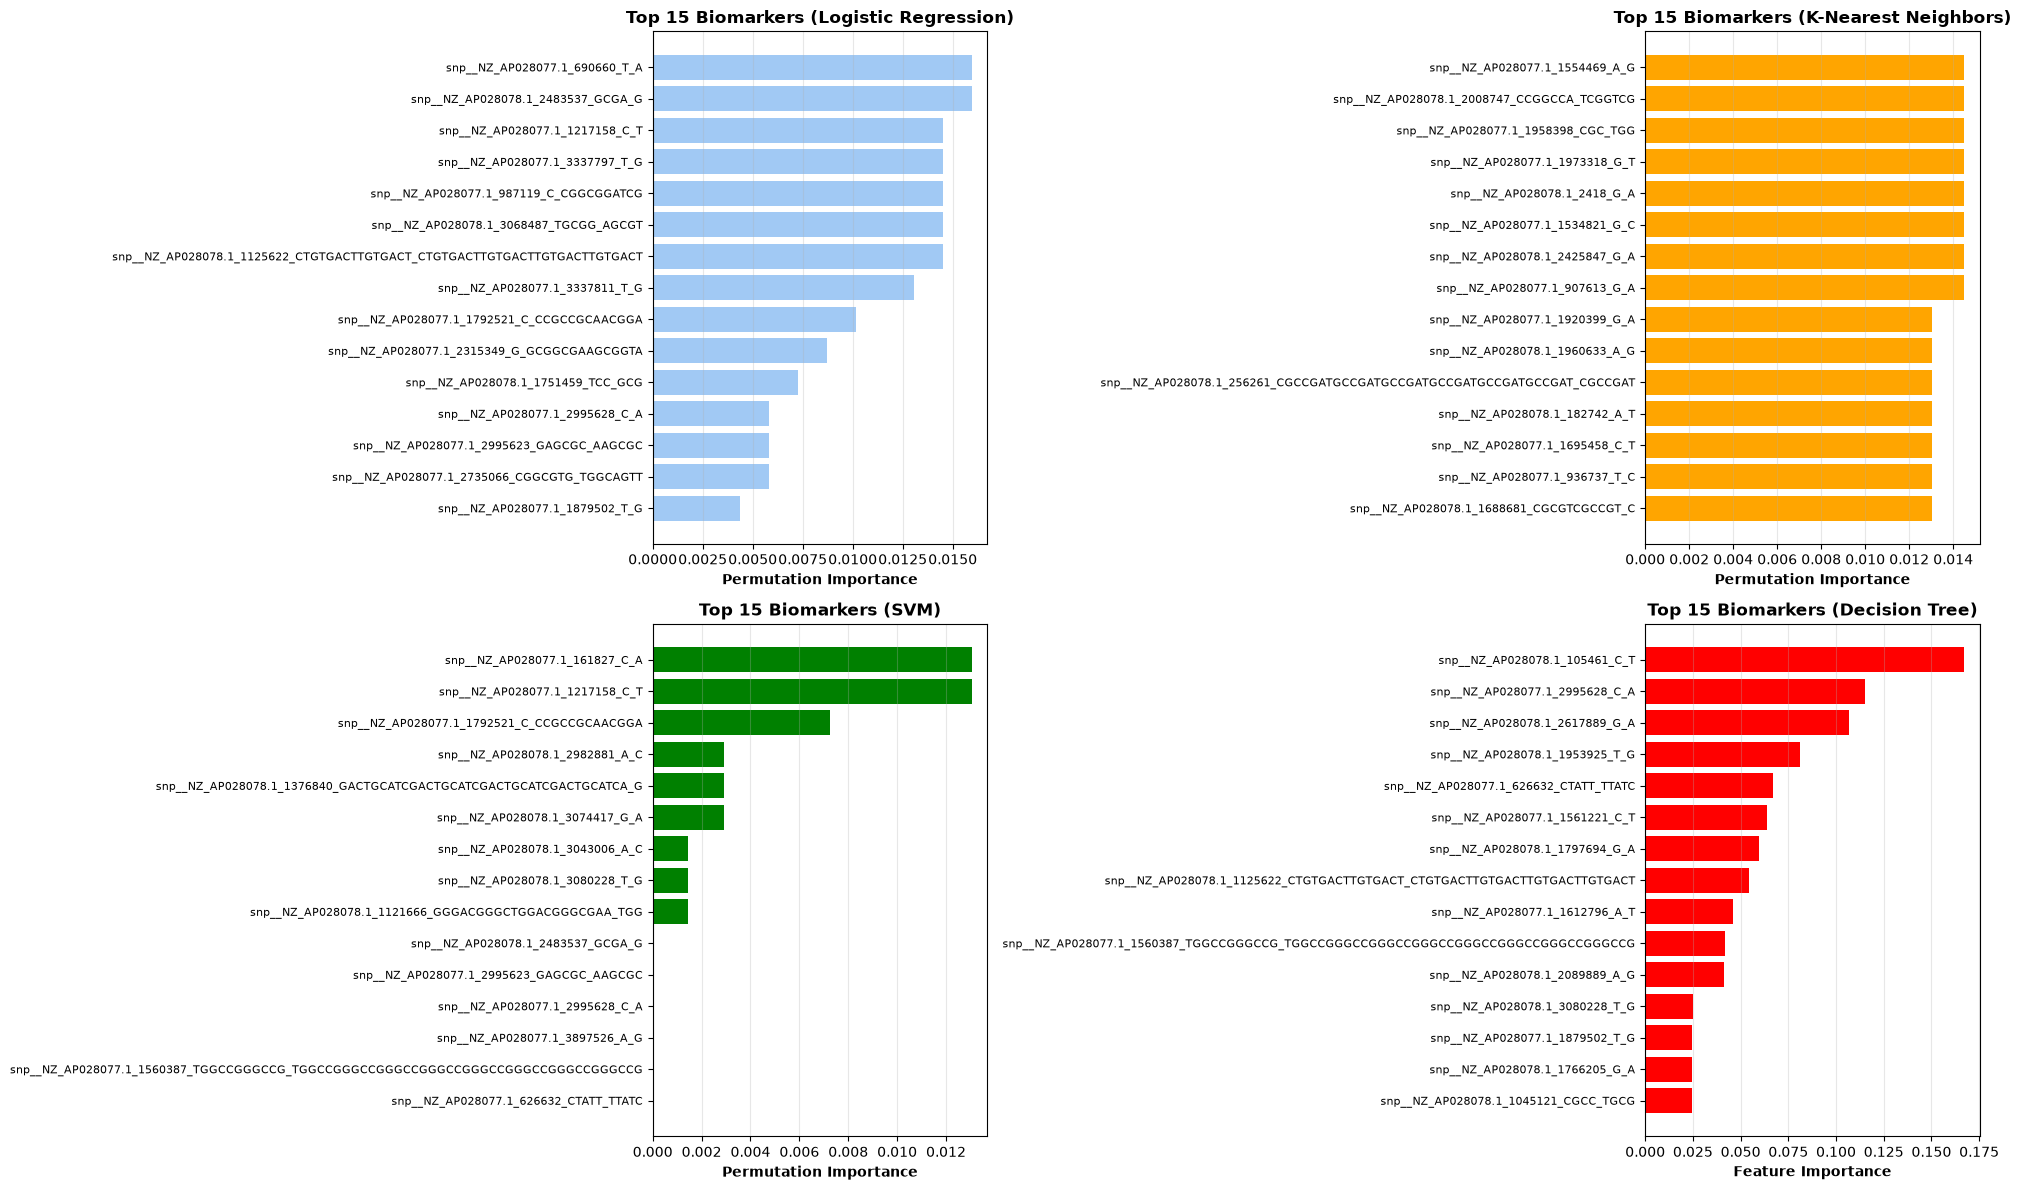

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Logistic Regression
ax = axes[0, 0]
top15_logreg = logreg_importance_df.head(15).iloc[::-1]
ax.barh(range(len(top15_logreg)), top15_logreg['importance_mean'])
ax.set_yticks(range(len(top15_logreg)))
ax.set_yticklabels(top15_logreg['snp_name'], fontsize=8)
ax.set_xlabel('Permutation Importance', fontweight='bold')
ax.set_title('Top 15 Biomarkers (Logistic Regression)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# K-Nearest Neighbors
ax = axes[0, 1]
top15_knn = knn_importance_df.head(15).iloc[::-1]
ax.barh(range(len(top15_knn)), top15_knn['importance_mean'], color='orange')
ax.set_yticks(range(len(top15_knn)))
ax.set_yticklabels(top15_knn['snp_name'], fontsize=8)
ax.set_xlabel('Permutation Importance', fontweight='bold')
ax.set_title('Top 15 Biomarkers (K-Nearest Neighbors)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Support Vector Machine
ax = axes[1, 0]
top15_svm = svm_importance_df.head(15).iloc[::-1]
ax.barh(range(len(top15_svm)), top15_svm['importance_mean'], color='green')
ax.set_yticks(range(len(top15_svm)))
ax.set_yticklabels(top15_svm['snp_name'], fontsize=8)
ax.set_xlabel('Permutation Importance', fontweight='bold')
ax.set_title('Top 15 Biomarkers (SVM)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Decision Tree
ax = axes[1, 1]
top15_dt = dt_importance_df.head(15).iloc[::-1]
ax.barh(range(len(top15_dt)), top15_dt['importance_mean'], color='red')
ax.set_yticks(range(len(top15_dt)))
ax.set_yticklabels(top15_dt['snp_name'], fontsize=8)
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title('Top 15 Biomarkers (Decision Tree)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### **5.2 Ranking Distribution Across Models**

In [23]:
# Assign ranks to each SNP in each model
logreg_ranks = logreg_importance_df.reset_index(drop=True).reset_index().rename(columns={'index': 'logreg_rank'})
knn_ranks = knn_importance_df.reset_index(drop=True).reset_index().rename(columns={'index': 'knn_rank'})
svm_ranks = svm_importance_df.reset_index(drop=True).reset_index().rename(columns={'index': 'svm_rank'})
dt_ranks = dt_importance_df.reset_index(drop=True).reset_index().rename(columns={'index': 'dt_rank'})

# Merge all ranks
ranking_df = logreg_ranks[['snp_name', 'logreg_rank']].copy()
ranking_df = ranking_df.merge(knn_ranks[['snp_name', 'knn_rank']], on='snp_name')
ranking_df = ranking_df.merge(svm_ranks[['snp_name', 'svm_rank']], on='snp_name')
ranking_df = ranking_df.merge(dt_ranks[['snp_name', 'dt_rank']], on='snp_name')

# Calculate mean rank
ranking_df['mean_rank'] = ranking_df[['logreg_rank', 'knn_rank', 'svm_rank', 'dt_rank']].mean(axis=1)
ranking_df = ranking_df.sort_values('mean_rank')

print("\nTop 20 SNPs by mean ranking across all models:")
print(ranking_df.head(20)[['snp_name', 'logreg_rank', 'knn_rank', 'svm_rank', 'dt_rank', 'mean_rank']])


Top 20 SNPs by mean ranking across all models:
                                              snp_name  logreg_rank  knn_rank  \
72               snp__NZ_AP028077.1_152334_GTCGT_ATCGC           72        46   
291                      snp__NZ_AP028078.1_182742_A_T          291        11   
266                        snp__NZ_AP028078.1_2418_G_A          266         4   
85   snp__NZ_AP028078.1_2298222_GTCGGCGGCCGGCAGTCGG...           85       328   
113                  snp__NZ_AP028078.1_802762_GCG_ACG          113       329   
84                      snp__NZ_AP028078.1_1130544_G_A           84       330   
96                       snp__NZ_AP028077.1_175281_G_A           96       315   
81                      snp__NZ_AP028078.1_2597401_C_T           81       334   
82                        snp__NZ_AP028077.1_47227_G_A           82       333   
83                      snp__NZ_AP028077.1_744705_GC_G           83       332   
76                        snp__NZ_AP028078.1_12044_A_G       

### **5.3 Heatmap of Top Biomarkers**

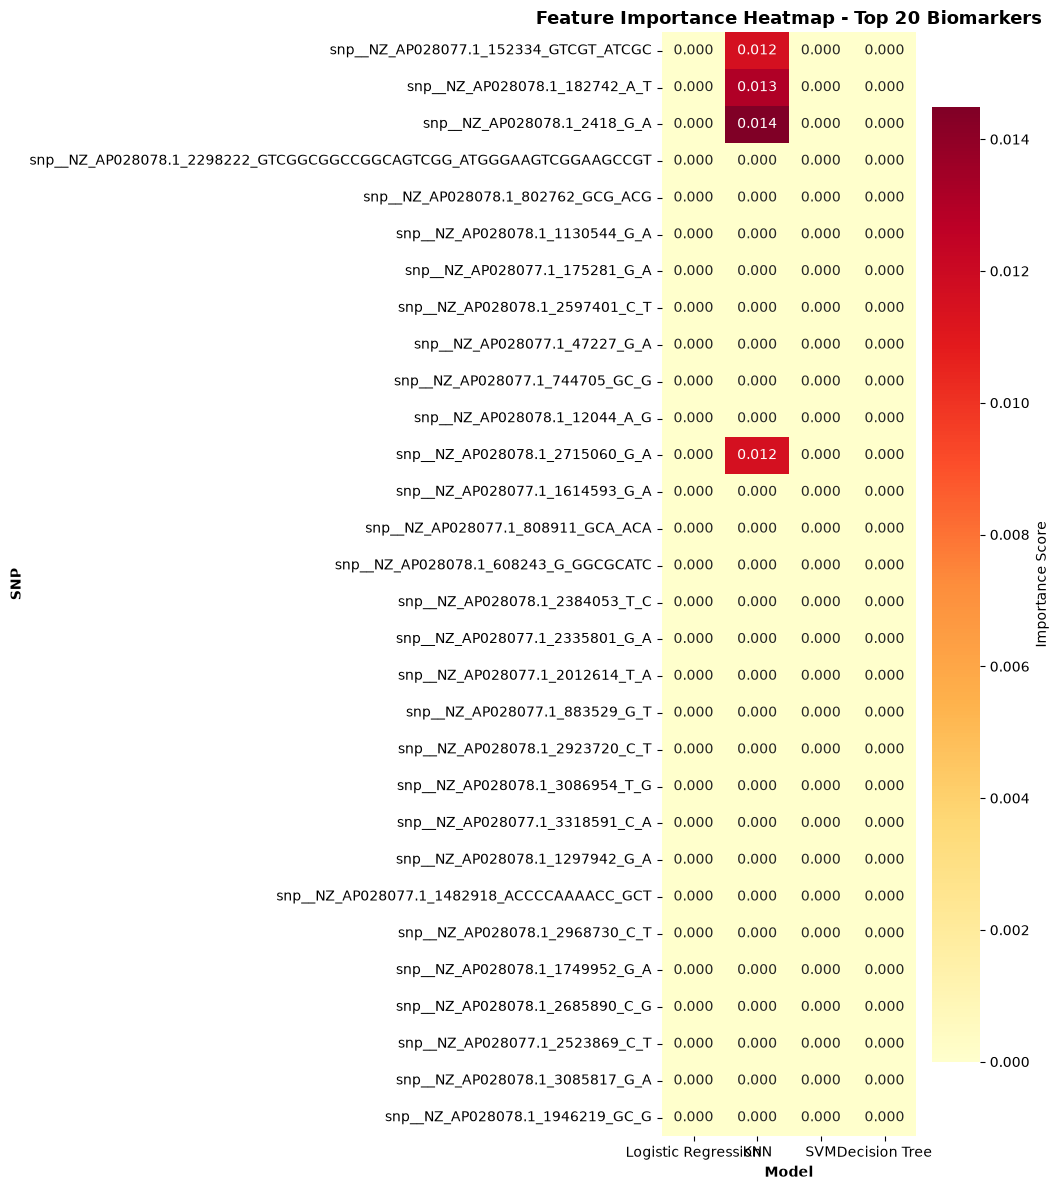

In [33]:
# Create heatmap of top 20 SNPs across models
top20_snps = ranking_df.head(30)['snp_name'].values

# Create importance matrix
importance_matrix = []
for snp in top20_snps:
    logreg_imp = logreg_importance_df[logreg_importance_df['snp_name'] == snp]['importance_mean'].values[0]
    knn_imp = knn_importance_df[knn_importance_df['snp_name'] == snp]['importance_mean'].values[0]
    svm_imp = svm_importance_df[svm_importance_df['snp_name'] == snp]['importance_mean'].values[0]
    dt_imp = dt_importance_df[dt_importance_df['snp_name'] == snp]['importance_mean'].values[0]
    importance_matrix.append([logreg_imp, knn_imp, svm_imp, dt_imp])

importance_matrix = np.array(importance_matrix)
heatmap_df = pd.DataFrame(
    importance_matrix,
    index=top20_snps,
    columns=['Logistic Regression', 'KNN', 'SVM', 'Decision Tree']
)

plt.figure(figsize=(10, 12))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Importance Score'})
plt.title('Feature Importance Heatmap - Top 20 Biomarkers', fontsize=13, fontweight='bold')
plt.xlabel('Model', fontweight='bold')
plt.ylabel('SNP', fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
svm_importance_df

,snp_index,snp_name,importance_mean,importance_std
5939,5939,snp__NZ_AP028077.1_161827_C_A,0.013043,0.004348
9576,9576,snp__NZ_AP028077.1_1217158_C_T,0.013043,0.004348
3105,3105,snp__NZ_AP028077.1_1792521_C_CCGCCGCAACGGA,0.007246,0.007246
3387,3387,snp__NZ_AP028078.1_2982881_A_C,0.002899,0.005797
7466,7466,snp__NZ_AP028078.1_1376840_GACTGCATCGACTGCATCG...,0.002899,0.005797
...,...,...,...,...
4441,4441,snp__NZ_AP028078.1_1769108_T_C,-0.015942,0.007805
8572,8572,snp__NZ_AP028078.1_296475_AA_CG,-0.017391,0.005797
6818,6818,snp__NZ_AP028077.1_1657487_AT_GC,-0.017391,0.005797
1160,1160,snp__NZ_AP028077.1_526639_C_CCGTTGGT,-0.017391,0.005797


## **6. Export Results**

In [27]:
# Export comprehensive biomarker list
biomarkers_export = ranking_df.copy()
biomarkers_export.to_csv('biomarkers_ranked.csv', index=False)

print("\nBiomarker analysis complete!")
print("\nExported files:")
print("  - biomarkers_ranked.csv: Ranked list of all SNPs with ranks from each model")
print("\nTop 20 candidate biomarkers for experimental validation:")
for i, (_, row) in enumerate(ranking_df.head(20).iterrows(), 1):
    print(f"  {i:2d}. {row['snp_name']:20s} (mean rank: {row['mean_rank']:6.1f})")


Biomarker analysis complete!

Exported files:
  - biomarkers_ranked.csv: Ranked list of all SNPs with ranks from each model

Top 20 candidate biomarkers for experimental validation:
   1. snp__NZ_AP028077.1_152334_GTCGT_ATCGC (mean rank:   85.8)
   2. snp__NZ_AP028078.1_182742_A_T (mean rank:  124.0)
   3. snp__NZ_AP028078.1_2418_G_A (mean rank:  136.0)
   4. snp__NZ_AP028078.1_2298222_GTCGGCGGCCGGCAGTCGG_ATGGGAAGTCGGAAGCCGT (mean rank:  147.2)
   5. snp__NZ_AP028078.1_802762_GCG_ACG (mean rank:  154.0)
   6. snp__NZ_AP028078.1_1130544_G_A (mean rank:  156.2)
   7. snp__NZ_AP028077.1_175281_G_A (mean rank:  157.8)
   8. snp__NZ_AP028078.1_2597401_C_T (mean rank:  161.0)
   9. snp__NZ_AP028077.1_47227_G_A (mean rank:  162.0)
  10. snp__NZ_AP028077.1_744705_GC_G (mean rank:  162.8)
  11. snp__NZ_AP028078.1_12044_A_G (mean rank:  178.0)
  12. snp__NZ_AP028078.1_2715060_G_A (mean rank:  184.8)
  13. snp__NZ_AP028077.1_1614593_G_A (mean rank:  194.2)
  14. snp__NZ_AP028077.1_808911_GCA_ACA